In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from neural_network.utils import build_covariance_matrix
from neural_network.trainer import HestonTrainer
from neural_network.config import HestonParams, HestonParamsMulti, ModelConfig
from neural_network.payoff import Put, PutProductMultipleAssets

In [2]:
exercise_type = "american"

n_assets = 2

S0 = 1.0   # Initial stock price
K = 1.0    # Strike price
T = 1.0      # Time to maturity
r = 0.05     # Risk-free rate
kappa = 2.0  # Mean reversion rate
theta = 0.04 # Long-term variance
sigma_bar = 0.3  # Volatility of variance
v0 = 0.04    # Initial variance

sigma = np.array([0.2, 0.25])  # Volatility of each asset

# Correlation matrix
rho_asset = 0.5
Sigma = np.full((n_assets, n_assets), rho_asset)
np.fill_diagonal(Sigma, 1.0)

rho_cross = [0.3, 0.4]  # Correlation between stock price and variance for each asset

S_min = 0.0
V_min = 0.05
S_max = 3 * S0
V_max = 5 * v0

params = HestonParamsMulti(
    n_assets=n_assets, S0=S0, v0=v0, r=r,
    kappa=kappa, theta=theta, sigma_bar=sigma_bar, sigma=sigma, Sigma=Sigma, rho=rho_cross, K=K, T=T,
    S_min=S_min, S_max=S_max, V_min=V_min, V_max=V_max
)


In [3]:
model_config = ModelConfig(
    input_size=n_assets + 2, # Stock prices + variance + time
    hidden_sizes=[64, 128, 128, 64],
    output_size=1,
    activation=nn.ReLU(),
    learning_rate=1e-3
)

payoff = PutProductMultipleAssets()

In [4]:
heston_trainer = HestonTrainer(model_config, params, payoff, exercise_type, seed=42)

Iteration 0, Loss: 5.017624855041504
Iteration 100, Loss: 0.3288704752922058
Iteration 200, Loss: 0.11285825818777084
Iteration 300, Loss: 0.05078532174229622
Iteration 400, Loss: 0.03863014653325081
Iteration 500, Loss: 0.02422342263162136
Iteration 600, Loss: 0.022329216822981834
Iteration 700, Loss: 0.020189490169286728
Iteration 800, Loss: 0.019407153129577637
Iteration 900, Loss: 0.016860075294971466
Iteration 1000, Loss: 0.013328357599675655
Iteration 1100, Loss: 0.012850480154156685
Iteration 1200, Loss: 0.011885581538081169
Iteration 1300, Loss: 0.014069593511521816
Iteration 1400, Loss: 0.011944020166993141
Iteration 1500, Loss: 0.010222846642136574
Iteration 1600, Loss: 0.012460906058549881
Early stopping at epoch 1624


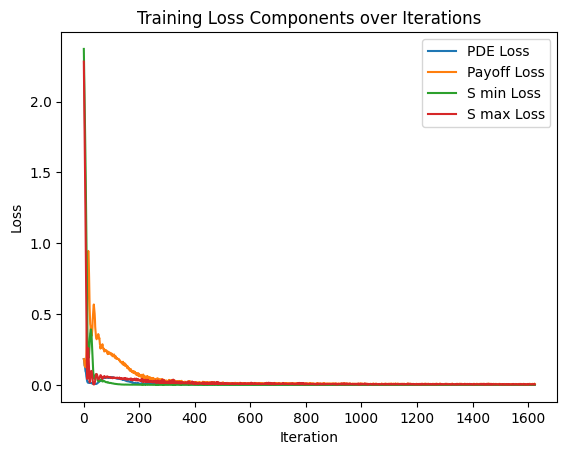

In [5]:
heston_trainer.train(batch_size=1024, epochs=10000, tol=1e-7)
heston_trainer.plot_losses_detailed()